# Introduction au projet

L’objectif de ce projet est de reconstruire des valeurs manquantes dans des séries temporelles de consommation électrique.  
Les données fournies correspondent à des mesures prises toutes les 30 minutes sur une période allant du 9 janvier 2023 au 31 janvier 2023.

Le problème consiste à estimer les valeurs manquantes présentes dans certaines séries, appelées `holed_...`.  
Comme nous disposons à la fois de données avec trous et des vraies valeurs associées pour l’entraînement, le projet peut être traité comme un problème d’**apprentissage supervisé**, plus précisément comme un problème de **régression**.

## Description des fichiers

### `X_train`

Le fichier `X_train` contient les données utilisées pour entraîner le modèle.  
Il contient une colonne `Horodate`, qui représente le temps, ainsi que de nombreuses colonnes correspondant à des séries temporelles.

Certaines colonnes, nommées `holed_1`, `holed_2`, ..., `holed_1000`, contiennent des valeurs manquantes.  
Ces colonnes représentent les séries que l’on cherche à reconstruire pendant l’entraînement.

En résumé :

- `X_train` correspond aux données d’entrée du modèle.
- Il contient les séries avec des trous.
- Il est utilisé avec `y_train` pour apprendre à retrouver les valeurs manquantes.

### `y_train`

Le fichier `y_train` contient les vraies valeurs associées aux colonnes `holed_...` présentes dans `X_train`.

Il joue le rôle de correction pendant l’entraînement.  
Pour chaque colonne `holed_...`, `y_train` donne les valeurs attendues, ce qui permet de comparer les prédictions du modèle avec les vraies réponses.

En résumé :

- `y_train` contient les bonnes réponses.
- Il sert de cible au modèle.
- Il permet d’évaluer l’erreur du modèle pendant l’apprentissage.

### `X_test`

Le fichier `X_test` contient les données sur lesquelles le modèle devra être appliqué une fois entraîné.

Comme `X_train`, il contient une colonne `Horodate` ainsi que des séries temporelles.  
Il contient également des colonnes `holed_1`, `holed_2`, ..., `holed_1000`, avec des valeurs manquantes à reconstruire.

La différence importante est que, pour `X_test`, les vraies valeurs ne sont pas fournies.  
Le modèle doit donc prédire ces valeurs à partir de ce qu’il a appris avec `X_train` et `y_train`.

En résumé :

- `X_test` correspond aux données finales.
- Il ne sert pas à entraîner le modèle.
- Il sert à produire les prédictions finales.

### `sample_submission`

Le fichier `sample_submission`, ou fichier d’exemple de sortie, indique le format attendu pour le rendu final.

Il contient une colonne `Horodate` et les colonnes `holed_1` à `holed_1000`.  
À la fin du projet, les prédictions générées à partir de `X_test` devront être enregistrées dans un fichier ayant la même structure.

En résumé :

- `sample_submission` sert de modèle pour le fichier final.
- Il indique les colonnes attendues.
- Il permet de savoir sous quel format rendre les prédictions.

In [36]:
import pandas as pd

X_train = pd.read_csv("X_train_78VdSWL.csv")
y_train = pd.read_csv("y_train_u0UkKEh.csv")
X_test = pd.read_csv("X_test_XKVc4no.csv")
sample_submission = pd.read_csv("new_output_sample.csv")

In [37]:
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test :", X_test.shape)
print("sample_submission :", sample_submission.shape)

X_train : (1057, 21001)
y_train : (1057, 1001)
X_test : (1057, 38141)
sample_submission : (1057, 1001)


## Première étape : préparation des données pour la régression

Pour entraîner un modèle de régression, il faut transformer les séries temporelles en un tableau classique de machine learning.

Dans notre cas, les valeurs à prédire sont les valeurs manquantes présentes dans les colonnes `holed_...` de `X_train`.

Pour chaque valeur manquante, on construit une ligne d'entraînement contenant plusieurs informations :

- l'heure de la journée ;
- le jour ;
- la valeur précédente connue dans la série ;
- la valeur suivante connue dans la série ;
- une première estimation par interpolation linéaire.

La cible associée est la vraie valeur présente dans `y_train`.

On obtient donc un problème de régression supervisée :

`variables explicatives → valeur réelle à reconstruire`

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split


In [40]:
X_train["Horodate"] = pd.to_datetime(X_train["Horodate"])
y_train["Horodate"] = pd.to_datetime(y_train["Horodate"])
X_test["Horodate"] = pd.to_datetime(X_test["Horodate"])
sample_submission["Horodate"] = pd.to_datetime(sample_submission["Horodate"])

In [41]:
holed_cols = [col for col in y_train.columns if col != "Horodate"]

print("Nombre de colonnes à reconstruire :", len(holed_cols))
print(holed_cols[:10])

Nombre de colonnes à reconstruire : 1000
['holed_1', 'holed_2', 'holed_3', 'holed_4', 'holed_5', 'holed_6', 'holed_7', 'holed_8', 'holed_9', 'holed_10']


In [42]:
def build_training_data(X, y, holed_cols):
    rows = []

    for col in holed_cols:
        # On récupère la série trouée dans X_train
        serie_with_holes = X[col]

        # On récupère les vraies valeurs dans y_train
        true_values = y[col]

        # On repère les positions où X_train a des valeurs manquantes
        missing_mask = serie_with_holes.isna()

        # Si la colonne n'a pas de trou, on passe à la suivante
        if missing_mask.sum() == 0:
            continue

        # Valeur précédente connue
        previous_values = serie_with_holes.ffill()

        # Valeur suivante connue
        next_values = serie_with_holes.bfill()

        # Interpolation linéaire simple
        interpolated_values = serie_with_holes.interpolate(method="linear").ffill().bfill()

        # Informations temporelles
        hours = X["Horodate"].dt.hour
        minutes = X["Horodate"].dt.minute
        days = X["Horodate"].dt.day
        dayofweek = X["Horodate"].dt.dayofweek

        for idx in X.index[missing_mask]:
            # On évite les lignes où la vraie réponse est absente
            if pd.isna(true_values.loc[idx]):
                continue

            rows.append({
                "colonne": col,
                "heure": hours.loc[idx],
                "minute": minutes.loc[idx],
                "jour": days.loc[idx],
                "jour_semaine": dayofweek.loc[idx],
                "valeur_precedente": previous_values.loc[idx],
                "valeur_suivante": next_values.loc[idx],
                "interpolation": interpolated_values.loc[idx],
                "cible": true_values.loc[idx]
            })

    return pd.DataFrame(rows)

In [43]:
train_data = build_training_data(X_train, y_train, holed_cols)

print(train_data.shape)
train_data.head()

(128853, 9)


,colonne,heure,minute,jour,jour_semaine,valeur_precedente,valeur_suivante,interpolation,cible
0,holed_1,4,0,9,0,1748.0,1317.0,1604.333333,1568.0
1,holed_1,4,30,9,0,1748.0,1317.0,1460.666667,1088.0
2,holed_1,11,0,9,0,1097.0,429.0,763.000000,492.0
3,holed_1,15,30,9,0,930.0,870.0,900.000000,726.0
4,holed_1,7,0,10,1,1083.0,1213.0,1148.000000,1174.0


In [44]:
train_data.isna().sum()

colonne                 0
heure                   0
minute                  0
jour                    0
jour_semaine            0
valeur_precedente    2633
valeur_suivante       199
interpolation           0
cible                   0
dtype: int64

In [45]:
# Correction cohérente des valeurs manquantes restantes
# Si le trou est au début d'une série, il peut manquer la valeur précédente.
# Si le trou est à la fin d'une série, il peut manquer la valeur suivante.
# Dans ces cas, on utilise l'interpolation, qui est une estimation locale de la valeur.

train_data["valeur_precedente"] = train_data["valeur_precedente"].fillna(train_data["interpolation"])
train_data["valeur_suivante"] = train_data["valeur_suivante"].fillna(train_data["interpolation"])

# Sécurité : s'il reste encore des lignes incomplètes, on les retire.
train_data = train_data.dropna()

print("Valeurs manquantes restantes :")
print(train_data.isna().sum())
print("Dimensions finales de train_data :", train_data.shape)


Valeurs manquantes restantes :
colonne              0
heure                0
minute               0
jour                 0
jour_semaine         0
valeur_precedente    0
valeur_suivante      0
interpolation        0
cible                0
dtype: int64
Dimensions finales de train_data : (128853, 9)


In [46]:
features = [
    "heure",
    "minute",
    "jour",
    "jour_semaine",
    "valeur_precedente",
    "valeur_suivante",
    "interpolation"
]

X_model = train_data[features]
y_model = train_data["cible"]

In [47]:
model = LinearRegression()
model.fit(X_model, y_model)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [48]:
y_pred = model.predict(X_model)

mse = mean_squared_error(y_model, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_model, y_pred)
r2 = r2_score(y_model, y_pred)

print("MSE :", mse)
print("RMSE :", rmse)
print("MAE :", mae)
print("R² :", r2)

MSE : 43139.40843922003
RMSE : 207.7002851206999
MAE : 108.55644239064125
R² : 0.786593387098039


## Entraînement du modèle

Le modèle utilisé ici est une régression linéaire.

Il apprend à estimer une valeur manquante à partir de plusieurs variables explicatives simples :

- la position temporelle de la valeur ;
- la valeur connue précédente ;
- la valeur connue suivante ;
- une estimation obtenue par interpolation.

Le modèle est entraîné avec les valeurs manquantes de `X_train`, tandis que les vraies valeurs correspondantes sont récupérées dans `y_train`.

Les métriques utilisées pour évaluer le modèle sont :

- la MSE, qui mesure l'erreur quadratique moyenne ;
- la RMSE, qui correspond à la racine de la MSE ;
- la MAE, qui mesure l'erreur absolue moyenne ;
- le score R², qui indique la part de variance expliquée par le modèle.

In [49]:
# train_test_split a déjà été importé au début du notebook.


In [50]:
X_model = train_data[features]
y_model = train_data["cible"]

X_train_model, X_val_model, y_train_model, y_val_model = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42
)

In [51]:
model = LinearRegression()
model.fit(X_train_model, y_train_model)

y_val_pred = model.predict(X_val_model)

mse = mean_squared_error(y_val_model, y_val_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val_model, y_val_pred)
r2 = r2_score(y_val_model, y_val_pred)

print("MSE validation :", mse)
print("RMSE validation :", rmse)
print("MAE validation :", mae)
print("R² validation :", r2)

MSE validation : 43234.25687643236
RMSE validation : 207.92848981424444
MAE validation : 109.2407377527819
R² validation : 0.78433760424312


In [52]:
final_model = LinearRegression()
final_model.fit(X_model, y_model)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Validation du modèle

Après séparation du jeu de données en une partie d'entraînement et une partie de validation, le modèle est évalué sur des exemples qu'il n'a pas utilisés directement pendant l'apprentissage.

Le score obtenu sur le jeu de validation est comparé au score obtenu sur les données d'entraînement. Si les deux scores sont proches, cela indique que le modèle conserve des performances similaires sur des données non vues. Cette observation est encourageante, car elle suggère que le modèle ne surapprend pas fortement les données d'entraînement.

Une fois la méthode validée, le modèle final est réentraîné sur l'ensemble des données disponibles afin d'utiliser un maximum d'informations avant de produire les prédictions finales sur `X_test`.


In [53]:
best_r2 = r2
best_features = features

print("Meilleur R² actuel :", best_r2)
print("Variables utilisées :", best_features)

Meilleur R² actuel : 0.78433760424312
Variables utilisées : ['heure', 'minute', 'jour', 'jour_semaine', 'valeur_precedente', 'valeur_suivante', 'interpolation']


In [54]:
X_model = train_data[best_features]
y_model = train_data["cible"]

final_model = LinearRegression()
final_model.fit(X_model, y_model)

print("Modèle final entraîné sur toutes les données.")

Modèle final entraîné sur toutes les données.


## Application du modèle sur X_test

Une fois le modèle validé, il peut être appliqué aux données de test.

Le fichier `X_test` contient les séries temporelles finales avec des valeurs manquantes.  
Contrairement à `X_train`, les vraies valeurs ne sont pas fournies. Le modèle entraîné doit donc prédire ces valeurs.

Pour cela, les données de `X_test` doivent être transformées exactement de la même manière que les données d'entraînement : extraction des informations temporelles, calcul de la valeur précédente, de la valeur suivante et de l'interpolation linéaire.

Les prédictions obtenues sont ensuite placées dans un fichier ayant le même format que `sample_submission`.

In [55]:
def build_test_data(X, holed_cols):
    rows = []

    for col in holed_cols:
        serie_with_holes = X[col]
        missing_mask = serie_with_holes.isna()

        if missing_mask.sum() == 0:
            continue

        previous_values = serie_with_holes.ffill()
        next_values = serie_with_holes.bfill()
        interpolated_values = serie_with_holes.interpolate(method="linear").ffill().bfill()

        hours = X["Horodate"].dt.hour
        minutes = X["Horodate"].dt.minute
        days = X["Horodate"].dt.day
        dayofweek = X["Horodate"].dt.dayofweek

        for idx in X.index[missing_mask]:
            rows.append({
                "index": idx,
                "Horodate": X.loc[idx, "Horodate"],
                "colonne": col,
                "heure": hours.loc[idx],
                "minute": minutes.loc[idx],
                "jour": days.loc[idx],
                "jour_semaine": dayofweek.loc[idx],
                "valeur_precedente": previous_values.loc[idx],
                "valeur_suivante": next_values.loc[idx],
                "interpolation": interpolated_values.loc[idx]
            })

    return pd.DataFrame(rows)

In [56]:
test_data = build_test_data(X_test, holed_cols)

print(test_data.shape)
test_data.head()

(128763, 10)


,index,Horodate,colonne,heure,minute,jour,jour_semaine,valeur_precedente,valeur_suivante,interpolation
0,4,2023-01-09 02:00:00,holed_1,2,0,9,0,998.0,1034.0,1016.000000
1,8,2023-01-09 04:00:00,holed_1,4,0,9,0,1003.0,1103.0,1053.000000
2,26,2023-01-09 13:00:00,holed_1,13,0,9,0,1259.0,1095.0,1204.333333
3,27,2023-01-09 13:30:00,holed_1,13,30,9,0,1259.0,1095.0,1149.666667
4,48,2023-01-10 00:00:00,holed_1,0,0,10,1,1171.0,979.0,1107.000000


In [57]:
try:
    selected_features = best_features
except NameError:
    selected_features = features

X_test_model = test_data[selected_features].copy()

# Remplacement intelligent :
# si la valeur précédente ou suivante manque, on utilise l'interpolation
if "valeur_precedente" in X_test_model.columns:
    X_test_model["valeur_precedente"] = X_test_model["valeur_precedente"].fillna(
        X_test_model["interpolation"]
    )

if "valeur_suivante" in X_test_model.columns:
    X_test_model["valeur_suivante"] = X_test_model["valeur_suivante"].fillna(
        X_test_model["interpolation"]
    )

# Sécurité finale : s'il reste encore des NaN, on utilise les moyennes du train
feature_means = train_data[selected_features].mean()
X_test_model = X_test_model.fillna(feature_means)

print("NaN après correction :")
print(X_test_model.isna().sum())
print("Total NaN :", X_test_model.isna().sum().sum())

test_data["prediction"] = final_model.predict(X_test_model)

test_data.head()

NaN après correction :
heure                0
minute               0
jour                 0
jour_semaine         0
valeur_precedente    0
valeur_suivante      0
interpolation        0
dtype: int64
Total NaN : 0


,index,Horodate,colonne,heure,minute,jour,jour_semaine,valeur_precedente,valeur_suivante,interpolation,prediction
0,4,2023-01-09 02:00:00,holed_1,2,0,9,0,998.0,1034.0,1016.000000,937.013197
1,8,2023-01-09 04:00:00,holed_1,4,0,9,0,1003.0,1103.0,1053.000000,971.651732
2,26,2023-01-09 13:00:00,holed_1,13,0,9,0,1259.0,1095.0,1204.333333,1098.772910
3,27,2023-01-09 13:30:00,holed_1,13,30,9,0,1259.0,1095.0,1149.666667,1083.200942
4,48,2023-01-10 00:00:00,holed_1,0,0,10,1,1171.0,979.0,1107.000000,1000.336084


In [58]:
submission = sample_submission.copy()

# On garde les horodates du fichier sample
submission["Horodate"] = sample_submission["Horodate"]

# On commence par recopier les valeurs connues de X_test
for col in holed_cols:
    submission[col] = X_test[col]

# Puis on remplace les trous par les prédictions du modèle
for _, row in test_data.iterrows():
    idx = row["index"]
    col = row["colonne"]
    pred = row["prediction"]
    submission.loc[idx, col] = pred

# Vérification
print(submission.shape)
print("Nombre de valeurs manquantes restantes :", submission.isna().sum().sum())

submission.head()

(1057, 1001)
Nombre de valeurs manquantes restantes : 0


,Horodate,holed_1,holed_2,holed_3,holed_4,holed_5,holed_6,holed_7,holed_8,holed_9,...,holed_991,holed_992,holed_993,holed_994,holed_995,holed_996,holed_997,holed_998,holed_999,holed_1000
0,2023-01-09 00:00:00,1061.000000,44.193574,100.669485,20.0,136.194654,148.0,70.0,183.0,88.0,...,38.0,168.0,32.0,284.671645,445.0,199.046878,52.391690,767.0,2029.0,129.000000
1,2023-01-09 00:30:00,1041.000000,44.143364,99.000000,42.0,138.000000,164.0,59.0,170.0,83.0,...,27.0,82.0,48.0,284.621435,492.0,207.000000,52.341480,773.0,1698.0,113.000000
2,2023-01-09 01:00:00,995.000000,44.788707,105.000000,19.0,145.000000,93.0,119.0,403.0,60.0,...,37.0,102.0,44.0,285.266779,461.0,218.000000,52.986823,613.0,1737.0,123.949473
3,2023-01-09 01:30:00,998.000000,44.738497,107.582749,34.0,270.000000,126.0,505.0,489.0,66.0,...,13.0,78.0,33.0,285.216569,491.0,104.000000,52.936613,691.0,994.0,135.000000
4,2023-01-09 02:00:00,937.013197,45.383841,107.000000,21.0,309.000000,1279.0,395.0,288.0,46.0,...,62.0,107.0,36.0,285.861912,451.0,97.000000,53.581957,844.0,1044.0,126.074381


In [59]:
submission.to_csv("submission_regression_lineaire.csv", index=False)

## Visualisation de la reconstruction

Afin de mieux comprendre le travail effectué par le modèle, une série temporelle de `X_test` est affichée à trois étapes différentes.

Le premier graphique montre la série originale avec les valeurs manquantes. On observe une interruption de la courbe au niveau du trou.

Le deuxième graphique montre une première reconstruction simple par interpolation linéaire. Cette méthode relie les valeurs connues avant et après le trou par une droite.

Le troisième graphique montre la reconstruction finale obtenue avec le modèle de régression entraîné. Cette visualisation permet de comparer la donnée initiale, une méthode simple de référence et le résultat final du modèle.


In [60]:
def find_good_gap_column(X, holed_cols, min_gap_size=4):
    """
    Cherche une colonne contenant un trou exploitable visuellement :
    - au moins min_gap_size valeurs manquantes consécutives
    - une valeur connue avant le trou
    - une valeur connue après le trou
    """
    best_col = None
    best_start = None
    best_end = None
    best_gap_size = 0

    for col in holed_cols:
        missing = X[col].isna().values
        n = len(missing)

        i = 0
        while i < n:
            if missing[i]:
                start = i

                while i < n and missing[i]:
                    i += 1

                end = i - 1
                gap_size = end - start + 1

                # On vérifie qu'il y a une valeur connue avant et après
                has_before = start > 0 and not pd.isna(X[col].iloc[start - 1])
                has_after = end < n - 1 and not pd.isna(X[col].iloc[end + 1])

                if has_before and has_after and gap_size >= min_gap_size:
                    if gap_size > best_gap_size:
                        best_col = col
                        best_start = start
                        best_end = end
                        best_gap_size = gap_size

            i += 1

    return best_col, best_start, best_end, best_gap_size


In [61]:
example_col, gap_start, gap_end, gap_size = find_good_gap_column(X_test, holed_cols)

print("Colonne choisie :", example_col)
print("Début du trou :", gap_start)
print("Fin du trou :", gap_end)
print("Taille du trou :", gap_size)

Colonne choisie : holed_807
Début du trou : 528
Fin du trou : 671
Taille du trou : 144


In [62]:
def plot_reconstruction_good_gap(X_original, submission, col, gap_start, gap_end, window=20):
    """
    Affiche une reconstruction autour d'un vrai trou entouré par des valeurs connues.
    """

    start_idx = max(0, gap_start - window)
    end_idx = min(len(X_original) - 1, gap_end + window)

    dates = X_original.loc[start_idx:end_idx, "Horodate"]

    original_values = X_original.loc[start_idx:end_idx, col]

    interpolation_values = (
        X_original[col]
        .interpolate(method="linear")
        .ffill()
        .bfill()
        .loc[start_idx:end_idx]
    )

    final_values = submission.loc[start_idx:end_idx, col]

    # Zone du trou
    gap_dates = X_original.loc[gap_start:gap_end, "Horodate"]

    # Graphe 1 : données originales
    plt.figure(figsize=(12, 5))
    plt.plot(dates, original_values, marker="o", label="Valeurs observées")
    plt.axvspan(gap_dates.iloc[0], gap_dates.iloc[-1], alpha=0.2, label="Zone manquante")
    plt.title(f"Série originale avec valeurs manquantes - {col}")
    plt.xlabel("Date")
    plt.ylabel("Valeur")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Graphe 2 : interpolation
    plt.figure(figsize=(12, 5))
    plt.plot(dates, original_values, marker="o", label="Valeurs observées")
    plt.plot(dates, interpolation_values, marker="o", label="Interpolation linéaire")
    plt.axvspan(gap_dates.iloc[0], gap_dates.iloc[-1], alpha=0.2, label="Zone reconstruite")
    plt.title(f"Reconstruction par interpolation linéaire - {col}")
    plt.xlabel("Date")
    plt.ylabel("Valeur")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Graphe 3 : modèle final
    plt.figure(figsize=(12, 5))
    plt.plot(dates, original_values, marker="o", label="Valeurs observées")
    plt.plot(dates, final_values, marker="o", label="Reconstruction finale")
    plt.axvspan(gap_dates.iloc[0], gap_dates.iloc[-1], alpha=0.2, label="Zone reconstruite")
    plt.title(f"Reconstruction finale par régression - {col}")
    plt.xlabel("Date")
    plt.ylabel("Valeur")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Graphe 4 : comparaison directe
    plt.figure(figsize=(12, 5))
    plt.plot(dates, interpolation_values, marker="o", label="Interpolation linéaire")
    plt.plot(dates, final_values, marker="o", label="Modèle de régression")
    plt.axvspan(gap_dates.iloc[0], gap_dates.iloc[-1], alpha=0.2, label="Zone reconstruite")
    plt.title(f"Comparaison interpolation / modèle - {col}")
    plt.xlabel("Date")
    plt.ylabel("Valeur")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()

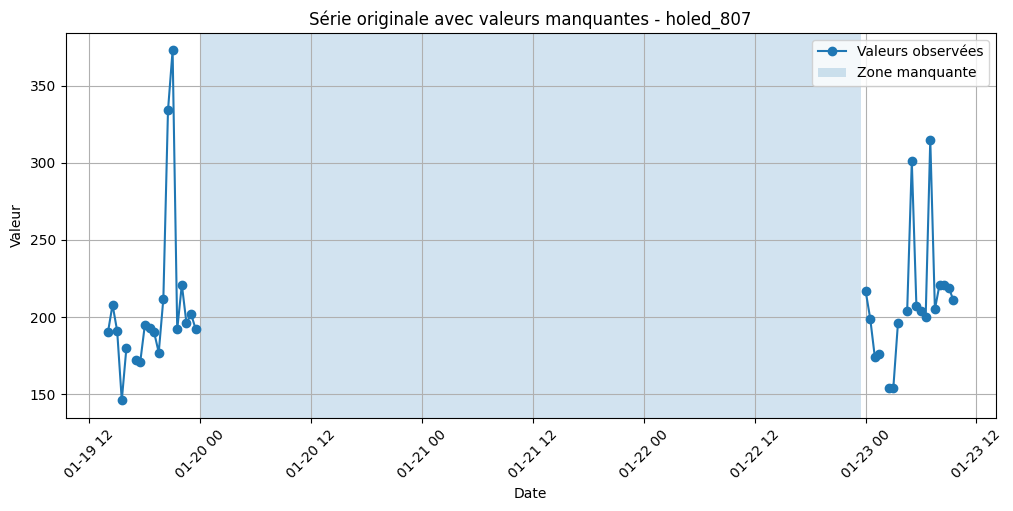

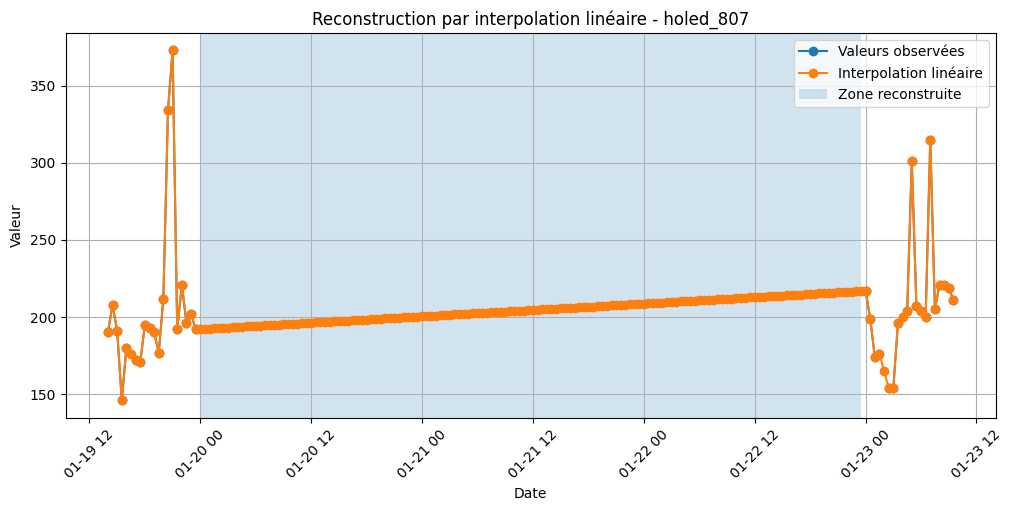

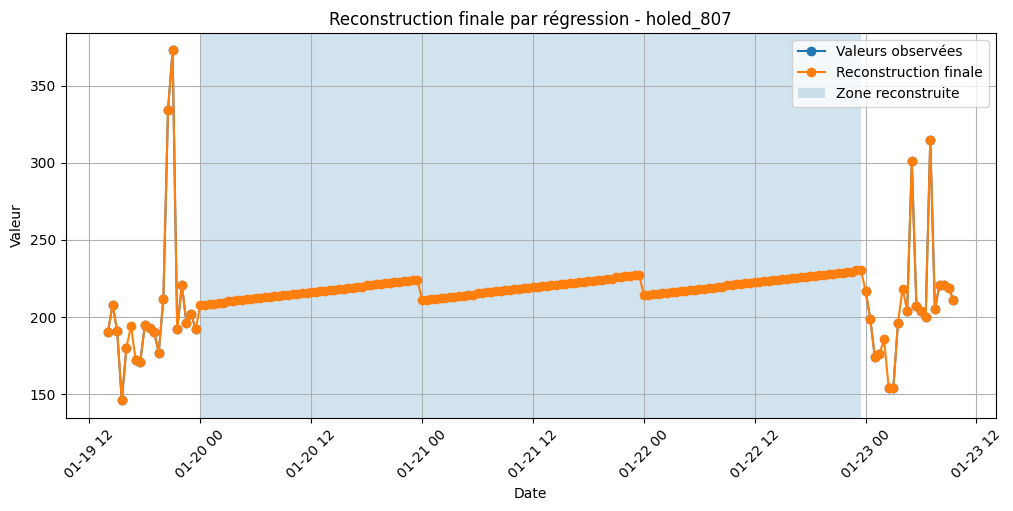

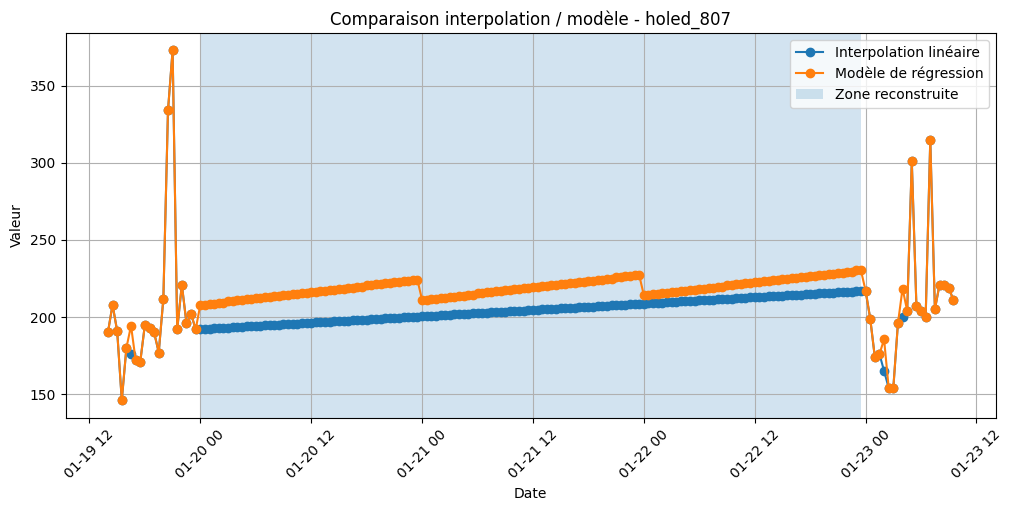

In [63]:
plot_reconstruction_good_gap(
    X_test,
    submission,
    example_col,
    gap_start,
    gap_end,
    window=20
)

## Conclusion

Ce notebook met en place une première solution complète pour reconstruire des valeurs manquantes dans des séries temporelles.

La méthode utilisée repose sur une régression linéaire supervisée. Pour chaque valeur manquante, plusieurs variables explicatives sont construites à partir du temps, des valeurs voisines et d’une interpolation linéaire.

Le modèle est d’abord évalué sur un jeu de validation, puis réentraîné sur toutes les données disponibles avant d’être appliqué à `X_test`.

Le fichier final `submission_regression_lineaire.csv` contient les prédictions au format attendu.


## Modèle amélioré : Gradient Boosting avec arbres de décision

La régression linéaire constitue une première approche simple et interprétable, directement liée aux notions vues en cours.

Cependant, les séries de consommation électrique peuvent contenir des relations non linéaires. Une régression linéaire peut donc être limitée, car elle cherche uniquement une combinaison linéaire des variables explicatives.

Pour améliorer les performances, nous testons un modèle basé sur des arbres de décision : le Gradient Boosting Regressor.

Le principe est d'entraîner plusieurs arbres successivement. Chaque nouvel arbre cherche à corriger les erreurs commises par les arbres précédents. Ce type de modèle est donc plus flexible qu'une régression linéaire simple.

Afin d'évaluer plus solidement ce modèle, nous utilisons une validation croisée KFold. Les données sont séparées plusieurs fois en ensembles d'entraînement et de validation, puis les scores sont moyennés.

In [64]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [65]:
try:
    selected_features = best_features
except NameError:
    selected_features = features

X_model = train_data[selected_features]
y_model = train_data["cible"]

print("Variables utilisées :", selected_features)
print("X_model :", X_model.shape)
print("y_model :", y_model.shape)
print("NaN dans X_model :", X_model.isna().sum().sum())

Variables utilisées : ['heure', 'minute', 'jour', 'jour_semaine', 'valeur_precedente', 'valeur_suivante', 'interpolation']
X_model : (128853, 7)
y_model : (128853,)
NaN dans X_model : 0


In [66]:
gb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    gb_model,
    X_model,
    y_model,
    cv=kfold,
    scoring="neg_mean_absolute_error"
)

mae_scores = -scores

print("MAE par fold :", mae_scores)
print("MAE moyenne :", mae_scores.mean())
print("Écart-type :", mae_scores.std())

MAE par fold : [94.8456099  94.83760792 96.49442302 93.62501985 93.97117088]
MAE moyenne : 94.75476631409194
Écart-type : 0.9931635930978191


In [67]:
mae_scores.mean()

np.float64(94.75476631409194)

In [68]:
gb_final_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

gb_final_model.fit(X_model, y_model)

print("Modèle Gradient Boosting final entraîné.")

Modèle Gradient Boosting final entraîné.


In [69]:
X_test_model_gb = test_data[selected_features].copy()

# Même correction que précédemment :
# si valeur_precedente ou valeur_suivante manque, on utilise l'interpolation
if "valeur_precedente" in X_test_model_gb.columns:
    X_test_model_gb["valeur_precedente"] = X_test_model_gb["valeur_precedente"].fillna(
        X_test_model_gb["interpolation"]
    )

if "valeur_suivante" in X_test_model_gb.columns:
    X_test_model_gb["valeur_suivante"] = X_test_model_gb["valeur_suivante"].fillna(
        X_test_model_gb["interpolation"]
    )

# Sécurité finale
feature_means = train_data[selected_features].mean()
X_test_model_gb = X_test_model_gb.fillna(feature_means)

print("NaN dans X_test_model_gb :", X_test_model_gb.isna().sum().sum())

NaN dans X_test_model_gb : 0


In [70]:
test_data["prediction_gb"] = gb_final_model.predict(X_test_model_gb)

test_data[["index", "colonne", "prediction_gb"]].head()

,index,colonne,prediction_gb
0,4,holed_1,995.863003
1,8,holed_1,940.472917
2,26,holed_1,1098.618609
3,27,holed_1,1050.639055
4,48,holed_1,915.867506


In [71]:
submission_gb = sample_submission.copy()

# On garde les horodates du fichier sample
submission_gb["Horodate"] = sample_submission["Horodate"]

# On recopie les valeurs connues de X_test
for col in holed_cols:
    submission_gb[col] = X_test[col]

# On remplace les valeurs manquantes par les prédictions Gradient Boosting
for _, row in test_data.iterrows():
    idx = row["index"]
    col = row["colonne"]
    pred = row["prediction_gb"]
    submission_gb.loc[idx, col] = pred

print("Dimensions :", submission_gb.shape)
print("Nombre de valeurs manquantes restantes :", submission_gb.isna().sum().sum())

submission_gb.head()

Dimensions : (1057, 1001)
Nombre de valeurs manquantes restantes : 0


,Horodate,holed_1,holed_2,holed_3,holed_4,holed_5,holed_6,holed_7,holed_8,holed_9,...,holed_991,holed_992,holed_993,holed_994,holed_995,holed_996,holed_997,holed_998,holed_999,holed_1000
0,2023-01-09 00:00:00,1061.000000,49.374368,106.568630,20.0,172.250094,148.0,70.0,183.0,88.0,...,38.0,168.0,32.0,277.373847,445.0,209.447554,48.896972,767.0,2029.0,129.000000
1,2023-01-09 00:30:00,1041.000000,49.374368,99.000000,42.0,138.000000,164.0,59.0,170.0,83.0,...,27.0,82.0,48.0,277.373847,492.0,207.000000,48.896972,773.0,1698.0,113.000000
2,2023-01-09 01:00:00,995.000000,49.305983,105.000000,19.0,145.000000,93.0,119.0,403.0,60.0,...,37.0,102.0,44.0,277.097016,461.0,218.000000,48.828586,613.0,1737.0,152.058891
3,2023-01-09 01:30:00,998.000000,49.305983,115.712151,34.0,270.000000,126.0,505.0,489.0,66.0,...,13.0,78.0,33.0,277.097016,491.0,104.000000,48.828586,691.0,994.0,135.000000
4,2023-01-09 02:00:00,995.863003,49.305983,107.000000,21.0,309.000000,1279.0,395.0,288.0,46.0,...,62.0,107.0,36.0,277.097016,451.0,97.000000,48.828586,844.0,1044.0,134.210557


In [72]:
submission_gb.to_csv("submission_gradient_boosting.csv", index=False)

print("Fichier créé : submission_gradient_boosting.csv")

Fichier créé : submission_gradient_boosting.csv


## Comparaison des modèles

Le modèle de régression linéaire a permis d'obtenir une première soumission valide et interprétable.  
Cependant, son score sur Challenge Data reste supérieur au benchmark attendu.

Le modèle Gradient Boosting est testé afin d'améliorer les performances.  
Contrairement à la régression linéaire, il peut modéliser des relations non linéaires entre les variables explicatives.

La validation croisée KFold permet d'obtenir une estimation plus stable de l'erreur moyenne du modèle.